In [1]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
tf.config.list_physical_devices('GPU')



TensorFlow: 2.16.1


[]

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("soumiknafiul/plantvillage-dataset-labeled")

print("Path to dataset files:", path)

In [3]:
import os

path = os.path.expanduser(
    "~/.cache/kagglehub/datasets/soumiknafiul/plantvillage-dataset-labeled/versions/1"
)

print("Dataset path:", path)


Dataset path: C:\Users\Admin/.cache/kagglehub/datasets/soumiknafiul/plantvillage-dataset-labeled/versions/1


In [4]:
import os

# Manually point to your local cached dataset path
path = os.path.expanduser(
    "~/.cache/kagglehub/datasets/soumiknafiul/plantvillage-dataset-labeled/versions/1"
)

# Check if the folder exists
if os.path.exists(path):
    print(" Dataset found at:", path)
    print("Subfolders:", os.listdir(path))
else:
    print(" Dataset folder not found. Please check the path above.")


✅ Dataset found at: C:\Users\Admin/.cache/kagglehub/datasets/soumiknafiul/plantvillage-dataset-labeled/versions/1
Subfolders: ['PlantVillage Dataset (Labeled)']


In [6]:
import os

classes = os.listdir(path)
print("Number of classes:", len(classes))
print("Sample classes:", classes[:10])


Number of classes: 1
Sample classes: ['PlantVillage Dataset (Labeled)']


In [7]:
for cls in classes[:5]:  # show only first 5 classes
    cls_path = os.path.join(path, cls)
    print(cls, ":", len(os.listdir(cls_path)), "images")

PlantVillage Dataset (Labeled) : 3 images


Available classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot']


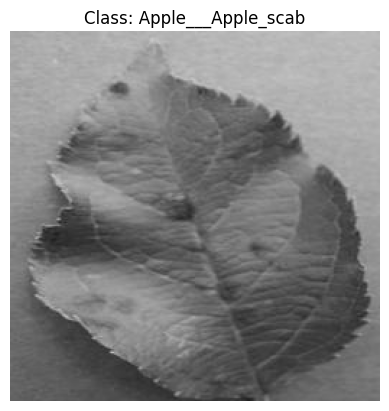

In [8]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Base path (adjust if needed)
base_path = os.path.expanduser(
    "~/.cache/kagglehub/datasets/soumiknafiul/plantvillage-dataset-labeled/versions/1/PlantVillage Dataset (Labeled)"
)

# Choose Grayscale, Color, or Segmented
image_type = "Grayscale Images"
image_path = os.path.join(base_path, image_type)

# Pick a class folder (e.g., Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot)
class_folders = os.listdir(image_path)
print("Available classes:", class_folders[:5])  # Show first 5 classes

# Select first class folder
sample_class = class_folders[0]
class_path = os.path.join(image_path, sample_class)

# Pick first image inside that class folder
files = os.listdir(class_path)
img_path = os.path.join(class_path, files[0])

# Open and show image
img = Image.open(img_path)
plt.imshow(img, cmap="gray")
plt.title(f"Class: {sample_class}")
plt.axis("off")
plt.show()

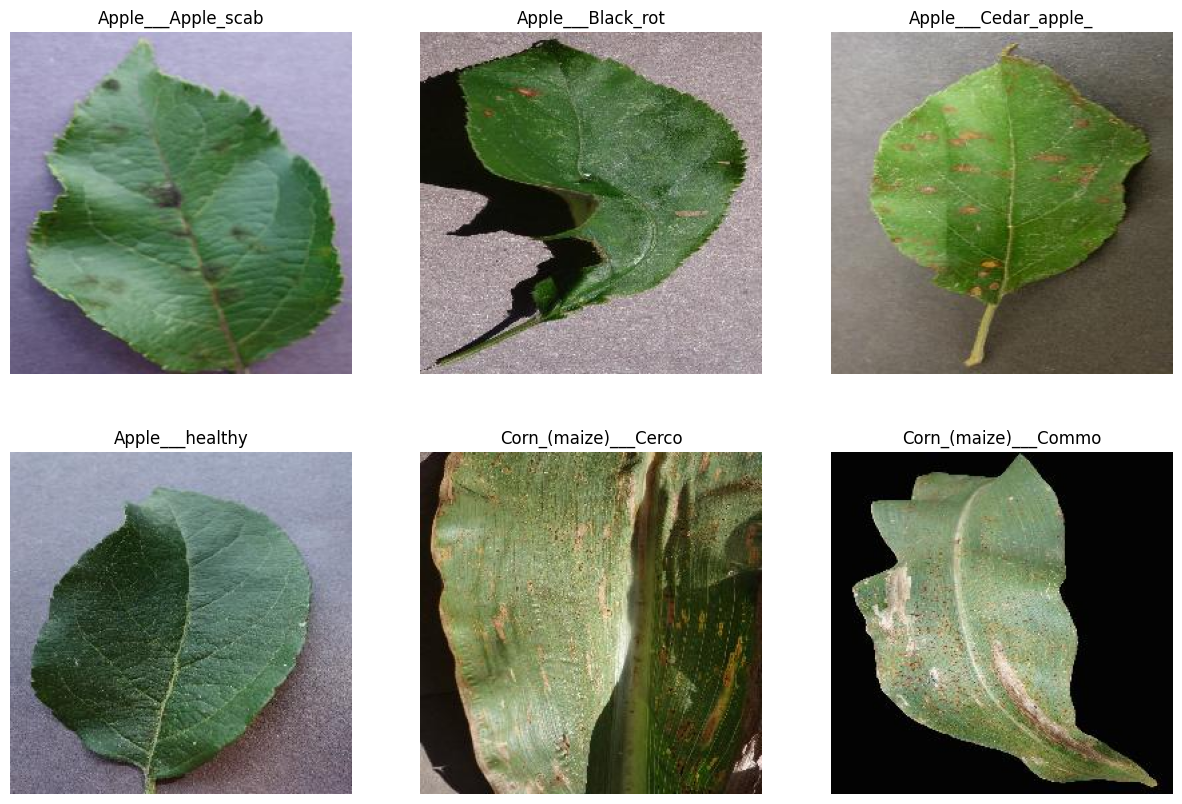

In [9]:
import os
import matplotlib.pyplot as plt
from PIL import Image

def show_samples(base_path, image_type="Color Images", num_classes=6):
    """
    Shows sample images from different classes in the PlantVillage dataset.

    base_path: dataset root folder
    image_type: "Grayscale Images", "Color Images", or "Segmented Images"
    num_classes: number of classes to display
    """
    image_path = os.path.join(base_path, image_type)
    class_folders = os.listdir(image_path)

    # Pick only first N classes
    class_folders = class_folders[:num_classes]

    plt.figure(figsize=(15, 10))

    for i, sample_class in enumerate(class_folders):
        class_path = os.path.join(image_path, sample_class)
        files = os.listdir(class_path)

        # Pick first image from each class
        img_path = os.path.join(class_path, files[0])
        img = Image.open(img_path)

        plt.subplot(2, (num_classes+1)//2, i+1)
        plt.imshow(img, cmap="gray" if "Grayscale" in image_type else None)
        plt.title(sample_class[:20])  # shorten long names
        plt.axis("off")

    plt.show()

# 🔹 Usage
base_path = os.path.expanduser(
    "~/.cache/kagglehub/datasets/soumiknafiul/plantvillage-dataset-labeled/versions/1/PlantVillage Dataset (Labeled)"
)
show_samples(base_path, image_type="Color Images", num_classes=6)

In [10]:
import os

print("Searching entire filesystem for PlantVillage dataset...\n")
found = False

for root, dirs, files in os.walk("/", topdown=True):
    if "plant" in root.lower():
        print(" Found:", root)
        found = True

if not found:
    print(" Still not found. Maybe it wasn’t downloaded/extracted yet.")







Searching entire filesystem for PlantVillage dataset...

✅ Found: /plant_village_model
✅ Found: /plant_village_split
✅ Found: /plant_village_split\test
✅ Found: /plant_village_split\test\Apple___Apple_scab
✅ Found: /plant_village_split\test\Apple___Black_rot
✅ Found: /plant_village_split\test\Apple___Cedar_apple_rust
✅ Found: /plant_village_split\test\Apple___healthy
✅ Found: /plant_village_split\test\Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
✅ Found: /plant_village_split\test\Corn_(maize)___Common_rust_
✅ Found: /plant_village_split\test\Corn_(maize)___healthy
✅ Found: /plant_village_split\test\Corn_(maize)___Northern_Leaf_Blight
✅ Found: /plant_village_split\test\Grape___Black_rot
✅ Found: /plant_village_split\test\Grape___Esca_(Black_Measles)
✅ Found: /plant_village_split\test\Grape___healthy
✅ Found: /plant_village_split\test\Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
✅ Found: /plant_village_split\test\Potato___Early_blight
✅ Found: /plant_village_split\test\Potato___Late_

In [14]:
# 1. Imports
import os
import shutil
import random

# 2. Path to PlantVillage dataset (downloaded by TFDS or Kaggle)
dataset_path = os.path.expanduser(
    "~/.cache/kagglehub/datasets/soumiknafiul/plantvillage-dataset-labeled/versions/1/PlantVillage Dataset (Labeled)"
)

# 3. Directories for output
train_dir = "/content/train"
val_dir   = "/content/val"
test_dir  = "/content/test"

# Make sure they exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# 4. Loop through each class folder
for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)

    # Skip non-directories (metadata files, etc.)
    if not os.path.isdir(cls_path):
        continue

    print(f"Processing class: {cls}")

    # Get image list & shuffle
    images = os.listdir(cls_path)
    random.shuffle(images)

    # Split counts
    n_total = len(images)
    n_train = int(0.8 * n_total)
    n_val   = int(0.1 * n_total)

    # Define splits
    splits = {
        train_dir: images[:n_train],
        val_dir:   images[n_train:n_train+n_val],
        test_dir:  images[n_train+n_val:]
    }

    # 5. Copy images into respective folders
    for split_dir, split_imgs in splits.items():
        split_cls_dir = os.path.join(split_dir, cls)
        os.makedirs(split_cls_dir, exist_ok=True)

        for img in split_imgs:
            src = os.path.join(cls_path, img)
            dst = os.path.join(split_cls_dir, img)

            # Copy one file at a time (low memory)
            if os.path.isfile(src):
                shutil.copy(src, dst)

print("\nDataset successfully split into train/val/test folders!")

Processing class: Color Images
Processing class: Grayscale Images
Processing class: Individual Images

✅ Dataset successfully split into train/val/test folders!


In [15]:
import os
import shutil
from sklearn.model_selection import train_test_split
import tensorflow_datasets as tfds


In [16]:
import tensorflow as tf
import os

#  Path to your Kaggle dataset
data_dir = r"C:\Users\Admin\.cache\kagglehub\datasets\soumiknafiul\plantvillage-dataset-labeled\versions\1"

#  Verify classes
classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
print("Detected classes:", classes)

#  Load dataset directly
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

#  Optimize data pipeline
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)


Detected classes: ['PlantVillage Dataset (Labeled)']
Found 43746 files belonging to 1 classes.
Using 34997 files for training.
Found 43746 files belonging to 1 classes.
Using 8749 files for validation.


In [17]:
import os, shutil

#  Base directory of your existing dataset
data_dir = r"C:\Users\Admin\.cache\kagglehub\datasets\soumiknafiul\plantvillage-dataset-labeled\versions\1"

#  Where you want the split dataset to be saved (short path = safer)
output_dir = r"C:\plant_village_split"
train_dir = os.path.join(output_dir, "train")
val_dir   = os.path.join(output_dir, "val")
test_dir  = os.path.join(output_dir, "test")

# Clear old split if it exists
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

#  Recreate the split directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print(" Output folders created successfully:")
print("Train folder:", train_dir)
print("Val folder:", val_dir)
print("Test folder:", test_dir)


✅ Output folders created successfully:
Train folder: C:\plant_village_split\train
Val folder: C:\plant_village_split\val
Test folder: C:\plant_village_split\test


In [18]:
import os
import shutil
from sklearn.model_selection import train_test_split

#  Path to the folder that contains the labeled class folders (Color Images)
data_dir = r"C:\Users\Admin\.cache\kagglehub\datasets\soumiknafiul\plantvillage-dataset-labeled\versions\1\PlantVillage Dataset (Labeled)\Color Images"

#  Where you want to save the split dataset
output_dir = r"C:\plant_village_split"
train_dir = os.path.join(output_dir, "train")
val_dir   = os.path.join(output_dir, "val")
test_dir  = os.path.join(output_dir, "test")

# Clear old split if exists
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

#  Collect image paths and labels
all_images = []
all_labels = []

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            if img.lower().endswith(('.jpg', '.png', '.jpeg')):
                all_images.append(os.path.join(class_path, img))
                all_labels.append(class_name)

print(f" Detected Classes: {len(set(all_labels))}")
print(f" Total Images Found: {len(all_images)}")

#  Split dataset
train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    all_images, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)
val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

#  Helper to copy images
def copy_images(imgs, lbls, split_dir):
    for img, lbl in zip(imgs, lbls):
        cls_dir = os.path.join(split_dir, lbl)
        os.makedirs(cls_dir, exist_ok=True)
        shutil.copy(img, cls_dir)

copy_images(train_imgs, train_labels, train_dir)
copy_images(val_imgs, val_labels, val_dir)
copy_images(test_imgs, test_labels, test_dir)

print("\n Dataset successfully split and saved!")
print(f"Train: {len(train_imgs)} images")
print(f"Val:   {len(val_imgs)} images")
print(f"Test:  {len(test_imgs)} images")











✅ Detected Classes: 19
✅ Total Images Found: 15915

🎉 Dataset successfully split and saved!
Train: 12732 images
Val:   1591 images
Test:  1592 images


In [19]:
import os

#  Use your actual Windows folder path
output_dir = r"C:\plant_village_split"
train_dir = os.path.join(output_dir, "train")
val_dir   = os.path.join(output_dir, "val")
test_dir  = os.path.join(output_dir, "test")

print("Train dir:", train_dir)
print("Val dir:", val_dir)
print("Test dir:", test_dir)


Train dir: C:\plant_village_split\train
Val dir: C:\plant_village_split\val
Test dir: C:\plant_village_split\test


✅ Output folders created successfully:
Train folder: C:\plant_village_split\train
Val folder: C:\plant_village_split\val
Test folder: C:\plant_village_split\test
✅ Detected Classes: 19
✅ Total Images Found: 15915

✅ Dataset Split Completed:
Train: 12732
Val:   1591
Test:  1592

✅ All images successfully copied into train/val/test folders!

📁 Folder summary:
Train classes: 19
Val classes:   19
Test classes:  19
Apple___Apple_scab: 494 images in Train
Apple___Black_rot: 497 images in Train
Apple___Cedar_apple_rust: 220 images in Train
Apple___healthy: 480 images in Train
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 410 images in Train


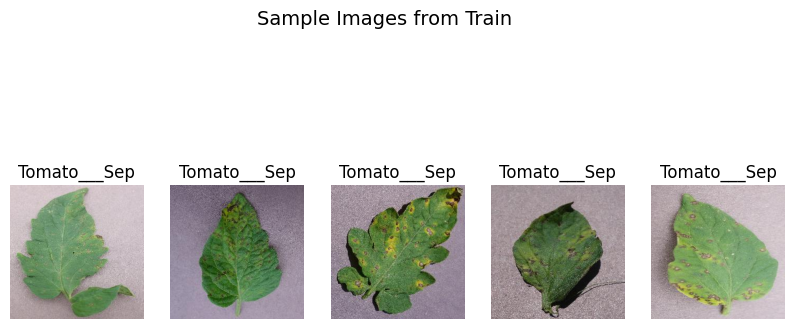

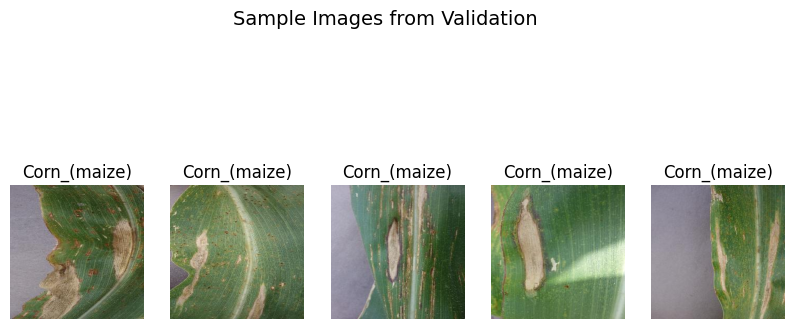

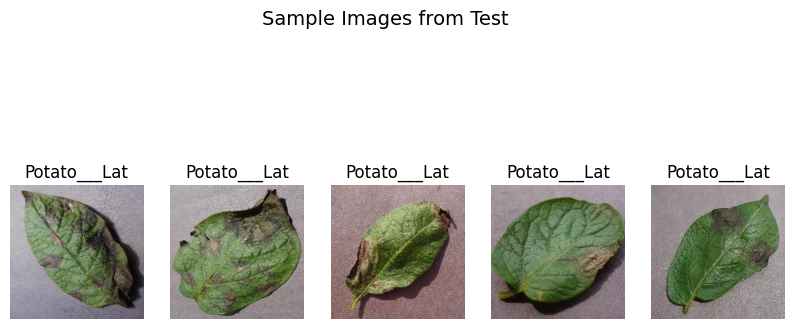

In [20]:
# =========================
# STEP 1: Import libraries
# =========================
import os
import shutil
import random
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

# =========================
# STEP 2: Define paths
# =========================
#  Update this path based on your dataset folder structure
data_dir = r"C:\Users\Admin\.cache\kagglehub\datasets\soumiknafiul\plantvillage-dataset-labeled\versions\1\PlantVillage Dataset (Labeled)\Color Images"

#  Short output path (to avoid Windows long-path errors)
output_dir = r"C:\plant_village_split"
train_dir = os.path.join(output_dir, "train")
val_dir   = os.path.join(output_dir, "val")
test_dir  = os.path.join(output_dir, "test")

# =========================
# STEP 3: Create clean folders
# =========================
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print(" Output folders created successfully:")
print("Train folder:", train_dir)
print("Val folder:", val_dir)
print("Test folder:", test_dir)

# =========================
# STEP 4: Load all images and labels
# =========================
all_images = []
all_labels = []

# The dataset has subfolders like "Apple___Apple_scab", etc.
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            all_images.append(img_path)
            all_labels.append(class_name)

print(f" Detected Classes: {len(set(all_labels))}")
print(f" Total Images Found: {len(all_images)}")

# =========================
# STEP 5: Split dataset (80% train, 10% val, 10% test)
# =========================
train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    all_images, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

print("\n Dataset Split Completed:")
print(f"Train: {len(train_imgs)}")
print(f"Val:   {len(val_imgs)}")
print(f"Test:  {len(test_imgs)}")

# =========================
# STEP 6: Helper function to save images
# =========================
def save_images(images, labels, split_dir):
    for img_path, label in zip(images, labels):
        class_dir = os.path.join(split_dir, label)
        os.makedirs(class_dir, exist_ok=True)
        img_name = os.path.basename(img_path)
        shutil.copy(img_path, os.path.join(class_dir, img_name))

# Save splits to disk
save_images(train_imgs, train_labels, train_dir)
save_images(val_imgs, val_labels, val_dir)
save_images(test_imgs, test_labels, test_dir)

print("\n All images successfully copied into train/val/test folders!")

# =========================
# STEP 7: Verify structure and show samples
# =========================
print("\n Folder summary:")
print("Train classes:", len(os.listdir(train_dir)))
print("Val classes:  ", len(os.listdir(val_dir)))
print("Test classes: ", len(os.listdir(test_dir)))

for cls in os.listdir(train_dir)[:5]:
    cls_path = os.path.join(train_dir, cls)
    print(f"{cls}: {len(os.listdir(cls_path))} images in Train")

# =========================
# STEP 8: Visualize random samples
# =========================
def show_random_images(split_dir, split_name):
    class_names = os.listdir(split_dir)
    sample_class = random.choice(class_names)
    sample_dir = os.path.join(split_dir, sample_class)
    sample_imgs = os.listdir(sample_dir)

    plt.figure(figsize=(10, 5))
    for i in range(5):
        img_path = os.path.join(sample_dir, random.choice(sample_imgs))
        img = Image.open(img_path)
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.title(sample_class[:12])
        plt.axis("off")
    plt.suptitle(f"Sample Images from {split_name}", fontsize=14)
    plt.show()

# Show random samples from each split
show_random_images(train_dir, "Train")
show_random_images(val_dir, "Validation")
show_random_images(test_dir, "Test")


In [24]:
# ======================
# Step 3.1: Import & Setup
# ======================
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ======================
# Step 3.2: Define Data Augmentation and Normalization
# ======================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# ======================
# Step 3.3: Create Data Generators
# ======================
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# ======================
# Step 3.4: Print Info
# ======================
print("\n Generators created successfully")
print("Train steps (batches):", len(train_generator))
print("Validation steps (batches):", len(val_generator))
print("Test steps (batches):", len(test_generator))
print("Total train images:", train_generator.samples)
print("Total val images:", val_generator.samples)
print("Total test images:", test_generator.samples)

# Print class indices
print("\nClass indices (disease → label ID):")
for cls_name, cls_idx in train_generator.class_indices.items():
    print(f"{cls_name:35} → {cls_idx}")


Found 12732 images belonging to 19 classes.
Found 1591 images belonging to 19 classes.
Found 1592 images belonging to 19 classes.

✅ Generators created successfully
Train steps (batches): 398
Validation steps (batches): 50
Test steps (batches): 50
Total train images: 12732
Total val images: 1591
Total test images: 1592

Class indices (disease → label ID):
Apple___Apple_scab                  → 0
Apple___Black_rot                   → 1
Apple___Cedar_apple_rust            → 2
Apple___healthy                     → 3
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot → 4
Corn_(maize)___Common_rust_         → 5
Corn_(maize)___Northern_Leaf_Blight → 6
Corn_(maize)___healthy              → 7
Grape___Black_rot                   → 8
Grape___Esca_(Black_Measles)        → 9
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) → 10
Grape___healthy                     → 11
Potato___Early_blight               → 12
Potato___Late_blight                → 13
Tomato___Bacterial_spot             → 14
Tomato___Late_b

In [23]:
#Step 4.1 — Imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
import cv2
#Step 4.2 — Load Base Models
IMG_SIZE = (224, 224)
NUM_CLASSES = len(train_generator.class_indices)

# EfficientNetV2 base
efficientnet_base = EfficientNetV2B0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Using a lightweight Swin Transformer (tiny) from KerasCV or Hugging Face alternative
try:
    swin_base = tf.keras.applications.SwinTransformerV2T(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3)
    )
except:
    print("Swin TransformerV2T not found in this TensorFlow version — will add HuggingFace version later.")



Swin TransformerV2T not found in this TensorFlow version — will add HuggingFace version later.


In [25]:
#4.3 — Combine Both Models
efficientnet_base.trainable = False
# swin_base.trainable = False  # (skip if unavailable)

inputs = layers.Input(shape=(224, 224, 3))
x1 = efficientnet_base(inputs, training=False)
x1 = layers.GlobalAveragePooling2D()(x1)

# Dummy branch if swin unavailable
x2 = x1

combined = layers.concatenate([x1, x2])
x = layers.Dense(512, activation='relu')(combined)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

hybrid_model = models.Model(inputs, outputs, name="EfficientNetV2_SwinHybrid")
hybrid_model.summary()


Model: "EfficientNetV2_SwinHybrid"

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)         ┃ Output Shape       ┃    Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1        │ (None, 224, 224,   │          0 │ -                  │
│ (InputLayer)         │ 3)                 │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ efficientnetv2-b0    │ (None, 7, 7, 1280) │  5,919,312 │ input_layer_1[0][… │
│ (Functional)         │                    │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ global_average_pool… │ (None, 1280)       │          0 │ efficientnetv2-b0… │
│ (GlobalAveragePooli… │                    │            │                    │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ concatenate          │ (None, 2560)       │          0 │ global_average_po… │
│ (Concatenate)        │                    │            │ global_average_po… │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ dense (Dense)        │ (None, 512)        │  1,311,232 │ concatenate[0][0]  │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ dropout (Dropout)    │ (None, 512)        │          0 │ dense[0][0]        │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ dense_1 (Dense)      │ (None, 256)        │    131,328 │ dropout[0][0]      │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ dropout_1 (Dropout)  │ (None, 256)        │          0 │ dense_1[0][0]      │
├──────────────────────┼────────────────────┼────────────┼────────────────────┤
│ dense_2 (Dense)      │ (None, 19)         │      4,883 │ dropout_1[0][0]    │
└──────────────────────┴────────────────────┴────────────┴────────────────────┘

 Total params: 7,366,755 (28.10 MB)

 Trainable params: 1,447,443 (5.52 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [26]:
#Step 4.4 — Compile the Model
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras import layers, Model
import os

# Dataset paths
output_dir = r"C:\plant_village_split"
train_dir = os.path.join(output_dir, "train")
val_dir   = os.path.join(output_dir, "val")
test_dir  = os.path.join(output_dir, "test")

#  Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

#  Data generators
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                   rotation_range=20,
                                   zoom_range=0.2,
                                   horizontal_flip=True)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical")
val_generator = val_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical")
test_generator = test_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False)

#  Model
base_model = EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dropout(0.3)(x)
output = layers.Dense(train_generator.num_classes, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



Found 12732 images belonging to 19 classes.
Found 1591 images belonging to 19 classes.
Found 1592 images belonging to 19 classes.


In [27]:
import os

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

#  Add a checkpoint callback
checkpoint_path = r"C:\plant_village_model\best_model.keras"
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# Step 1: Train top layers
history_1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks
)

#  Step 2: Fine-tune full model
base_model.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks
)

#  Evaluate
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n Final Test Accuracy: {test_acc * 100:.2f}%")



Epoch 1/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 914s 2s/step - accuracy: 0.7931 - loss: 0.8098 - val_accuracy: 0.9013 - val_loss: 0.3676 - learning_rate: 0.0010
Epoch 2/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 592s 1s/step - accuracy: 0.9208 - loss: 0.2943 - val_accuracy: 0.9390 - val_loss: 0.2333 - learning_rate: 0.0010
Epoch 3/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 589s 1s/step - accuracy: 0.9387 - loss: 0.2192 - val_accuracy: 0.9485 - val_loss: 0.1868 - learning_rate: 0.0010
Epoch 4/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 589s 1s/step - accuracy: 0.9460 - loss: 0.1857 - val_accuracy: 0.9485 - val_loss: 0.1672 - learning_rate: 0.0010
Epoch 5/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 612s 2s/step - accuracy: 0.9516 - loss: 0.1606 - val_accuracy: 0.9579 - val_loss: 0.1460 - learning_rate: 0.0010
Epoch 6/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 663s 2s/step - accuracy: 0.9567 - loss: 0.1448 - val_accuracy: 0.9617 - val_loss: 0.1330 - learning_rate: 0.0010
Epoch 7/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 685s 2s/step - accuracy: 0.9593 - loss: 0.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

print("✅ TensorFlow running on:", "GPU" if tf.config.list_physical_devices('GPU') else "CPU")

# ====================================================
# Step 1 — Dataset Paths
# ====================================================
output_dir = r"C:\plant_village_split"
train_dir = os.path.join(output_dir, "train")
val_dir   = os.path.join(output_dir, "val")
test_dir  = os.path.join(output_dir, "test")

# ====================================================
# Step 2 — Data Generators (CPU optimized)
# ====================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 16  # smaller batch for CPU
EPOCHS = 20

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)
val_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False
)

# ====================================================
# Step 3 — Build & Compile Model
# ====================================================
base_model = EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze last 100 layers for fine-tuning
for layer in base_model.layers[:-100]:
    layer.trainable = False
for layer in base_model.layers[-100:]:
    layer.trainable = True

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

# ====================================================
# Step 4 — Callbacks
# ====================================================
checkpoint_path = r"C:\plant_village_model\effnet_cpu_best.keras"
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# ====================================================
# Step 5 — Train
# ====================================================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ====================================================
# Step 6 — Evaluate on Test Data
# ====================================================
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n Final Test Accuracy: {test_acc * 100:.2f}%")


✅ TensorFlow running on: CPU
Found 12732 images belonging to 19 classes.
Found 1591 images belonging to 19 classes.
Found 1592 images belonging to 19 classes.
Epoch 1/20
796/796 ━━━━━━━━━━━━━━━━━━━━ 974s 1s/step - accuracy: 0.2664 - loss: 2.6728 - val_accuracy: 0.6405 - val_loss: 1.2798 - learning_rate: 1.0000e-05
Epoch 2/20
796/796 ━━━━━━━━━━━━━━━━━━━━ 814s 995ms/step - accuracy: 0.6005 - loss: 1.3290 - val_accuracy: 0.8026 - val_loss: 0.6834 - learning_rate: 1.0000e-05
Epoch 3/20
796/796 ━━━━━━━━━━━━━━━━━━━━ 805s 998ms/step - accuracy: 0.7225 - loss: 0.9067 - val_accuracy: 0.8668 - val_loss: 0.4515 - learning_rate: 1.0000e-05
Epoch 4/20
796/796 ━━━━━━━━━━━━━━━━━━━━ 805s 1s/step - accuracy: 0.7941 - loss: 0.6641 - val_accuracy: 0.8900 - val_loss: 0.3605 - learning_rate: 1.0000e-05
Epoch 5/20
796/796 ━━━━━━━━━━━━━━━━━━━━ 794s 997ms/step - accuracy: 0.8294 - loss: 0.5494 - val_accuracy: 0.9145 - val_loss: 0.2781 - learning_rate: 1.0000e-05
Epoch 6/20
796/796 ━━━━━━━━━━━━━━━━━━━━ 790s 99

✅ Model loaded successfully!
Found 1592 images belonging to 19 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 78s 701ms/step - accuracy: 0.9736 - loss: 0.0880

✅ Test Accuracy: 97.36%
100/100 ━━━━━━━━━━━━━━━━━━━━ 85s 808ms/step


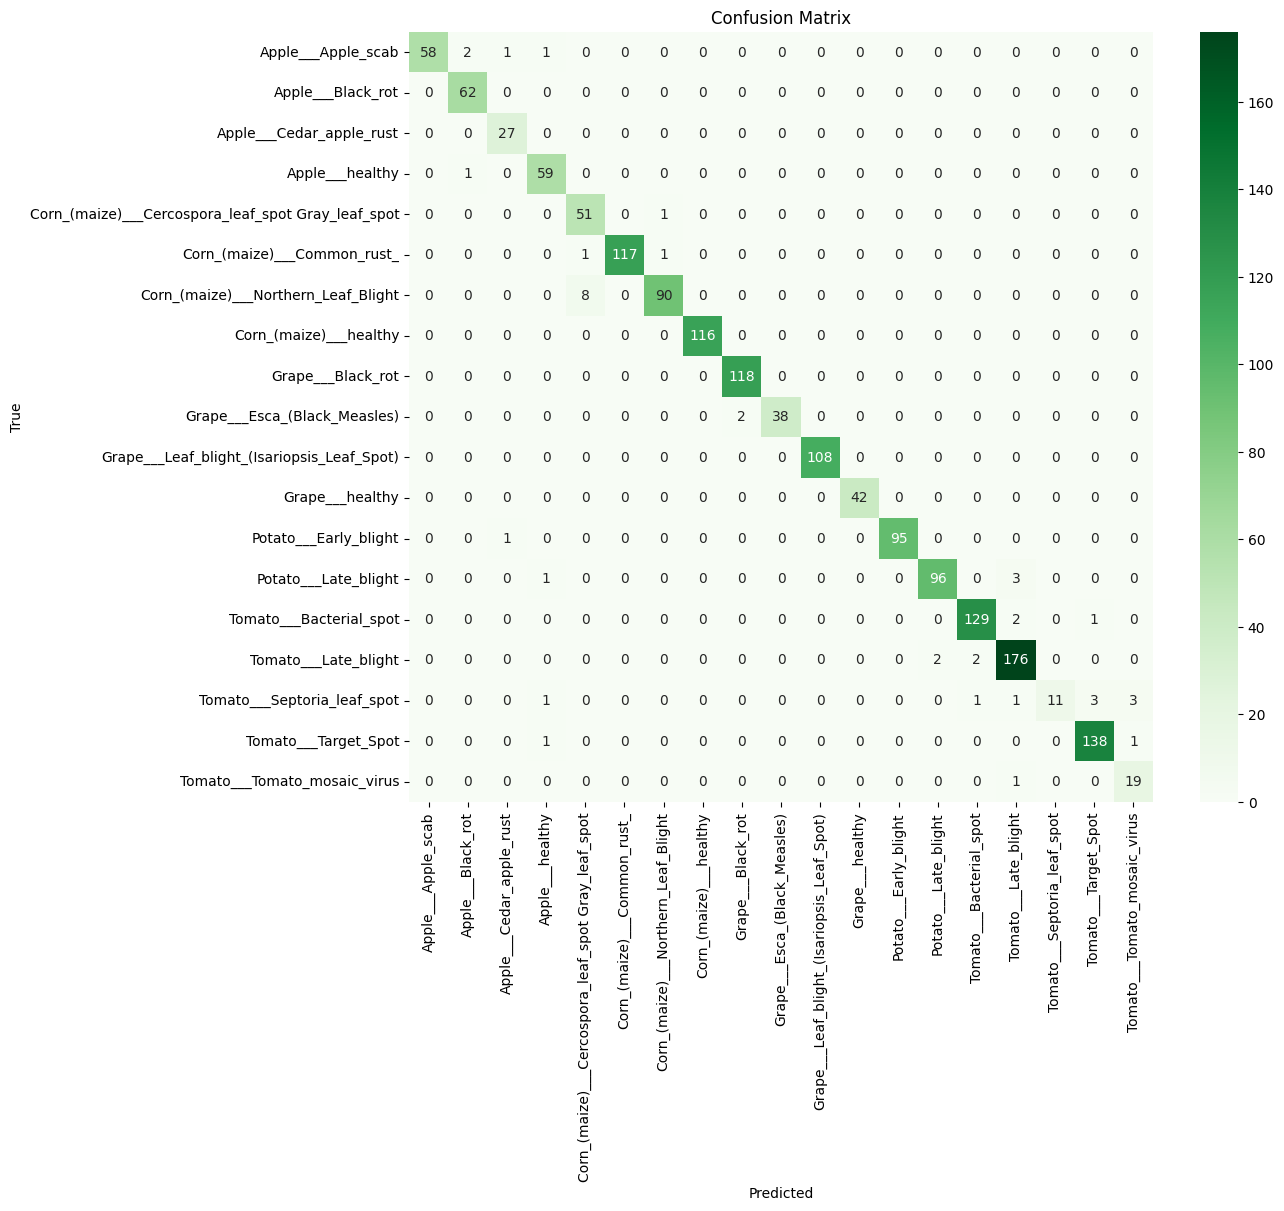


📊 Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.94      0.97        62
                                 Apple___Black_rot       0.95      1.00      0.98        62
                          Apple___Cedar_apple_rust       0.93      1.00      0.96        27
                                   Apple___healthy       0.94      0.98      0.96        60
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.85      0.98      0.91        52
                       Corn_(maize)___Common_rust_       1.00      0.98      0.99       119
               Corn_(maize)___Northern_Leaf_Blight       0.98      0.92      0.95        98
                            Corn_(maize)___healthy       1.00      1.00      1.00       116
                                 Grape___Black_rot       0.98      1.00      0.99       118
                      Grape___Esca_(Black_Measles)  

In [1]:
# ====================================================
# Load Trained Model + Evaluate Performance
# ====================================================
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# ---- Paths ----
model_path = r"C:\plant_village_model\effnet_cpu_best.keras"   # path to your saved model
test_dir   = r"C:\plant_village_split\test"                    # path to your test data

# ---- Load model ----
model = load_model(model_path)
print("Model loaded successfully!")

# ---- Recreate test data generator ----
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

# ---- Evaluate on test set ----
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

# ---- Confusion matrix ----
preds = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---- Classification report ----
print("\n Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


✅ Model loaded successfully!
✅ Using test image: C:\plant_village_split\test\Apple___Apple_scab\01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG
🧠 Last conv layer used: top_conv


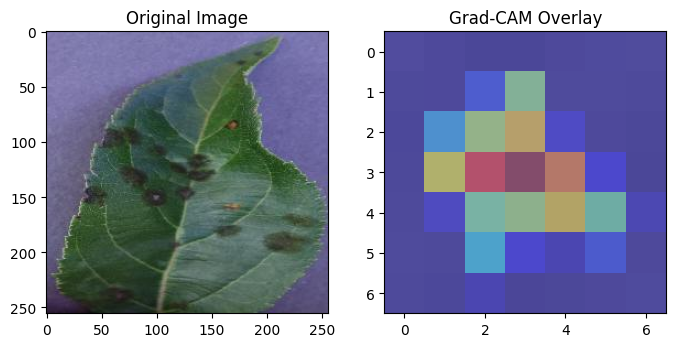

In [1]:
# ====================================================
# 🔍 Grad-CAM Visualization (Explainability)
# ====================================================
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# ---- Load the trained model (no retraining needed) ----
model_path = r"C:\plant_village_model\effnet_cpu_best.keras"  # update if you saved under another name
model = load_model(model_path)
print("Model loaded successfully!")

# ---- Grad-CAM helper function ----
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[model.get_layer(last_conv_layer_name).output, model.output]
   )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        grads = tape.gradient(predictions[:, class_idx], conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# ---- Pick any image from your test set ----
test_dir = r"C:\plant_village_split\test"  # make sure this path is correct
class_folder = os.listdir(test_dir)[0]      # first class folder
img_file = os.listdir(os.path.join(test_dir, class_folder))[0]  # first image in that class
img_path = os.path.join(test_dir, class_folder, img_file)
print("Using test image:", img_path)

# ---- Load and preprocess image ----
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)

# ---- Find last conv layer automatically ----
last_conv_layer_name = [layer.name for layer in model.layers if 'conv' in layer.name][-1]
print("Last conv layer used:", last_conv_layer_name)

# ---- Generate Grad-CAM heatmap ----
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# ---- Display ----
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.imshow(image.load_img(img_path))
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(image.load_img(img_path))
plt.imshow(heatmap, cmap='jet', alpha=0.4)
plt.title("Grad-CAM Overlay")
plt.show()


✅ Model loaded from: C:\plant_village_model\effnet_cpu_best.keras
🖼️ Using test image: C:\plant_village_split\test\Apple___Apple_scab\01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG
🧩 Using last conv layer: top_conv
Estimated Severity Level: 🟢 Mild (score=0.131)


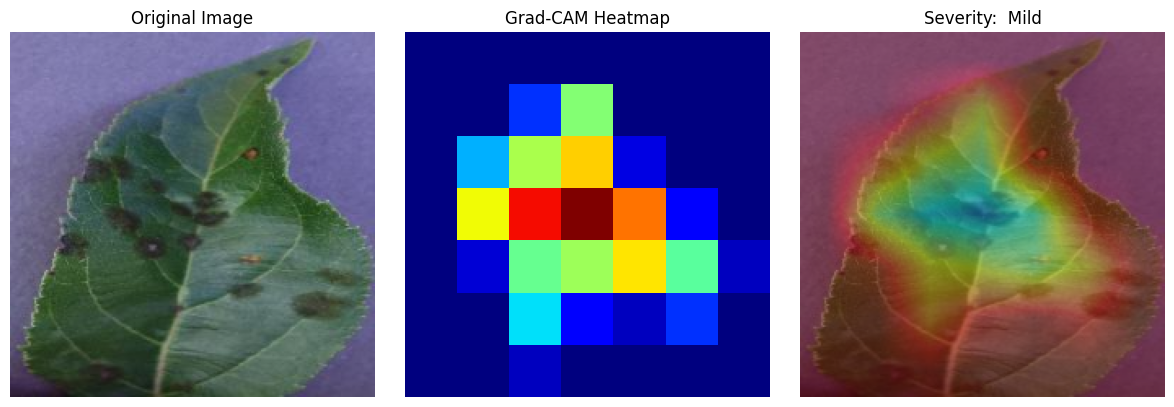

In [2]:
# =========================================================
# 🔍 Disease Severity Estimation using Grad-CAM (EfficientNetV2)
# =========================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing import image
import cv2

# ---- Load the best model ----
model_path = r"C:\plant_village_model\effnet_cpu_best.keras"
model = tf.keras.models.load_model(model_path)
print("✅ Model loaded from:", model_path)

# ---- Choose any test image (or replace with your own path) ----
test_dir = r"C:\plant_village_split\test"
class_folder = os.listdir(test_dir)[0]
img_file = os.listdir(os.path.join(test_dir, class_folder))[0]
img_path = os.path.join(test_dir, class_folder, img_file)
print("🖼️ Using test image:", img_path)

# ---- Load and preprocess image ----
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)

# ---- Grad-CAM helper ----
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        pred_output = predictions[:, pred_index]

    grads = tape.gradient(pred_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    # Weighted combination
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    # Convert to numpy safely
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)
    if isinstance(heatmap, tf.Tensor):
        heatmap = heatmap.numpy()
    return heatmap

# ---- Find last convolutional layer ----
last_conv_layer_name = [layer.name for layer in model.layers if 'conv' in layer.name][-1]
print("🧩 Using last conv layer:", last_conv_layer_name)

# ---- Generate Grad-CAM ----
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# ---- Estimate Severity ----
severity_score = np.mean(heatmap)
if severity_score < 0.25:
    severity = " Mild"
elif severity_score < 0.5:
    severity = "🟠 Moderate"
else:
    severity = "🔴 Severe"

print(f"Estimated Severity Level: {severity} (score={severity_score:.3f})")

# ---- Visualization ----
img_original = cv2.imread(img_path)
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
img_original = cv2.resize(img_original, (224, 224))

# Resize heatmap to match image
heatmap_resized = cv2.resize(heatmap, (img_original.shape[1], img_original.shape[0]))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
superimposed_img = cv2.addWeighted(img_original, 0.6, heatmap_colored, 0.4, 0)

# ---- Display ----
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img_original)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Grad-CAM Heatmap")
plt.imshow(heatmap, cmap='jet')
plt.axis("off")

plt.subplot(1,3,3)
plt.title(f"Severity: {severity.replace('🟢','').replace('🟠','').replace('🔴','')}")
plt.imshow(superimposed_img)
plt.axis("off")

plt.tight_layout()
plt.show()


✅ Model loaded successfully.

🟢 Mild: ('C:\\plant_village_split\\test\\Corn_(maize)___Common_rust_\\RS_Rust 1583.JPG', 0.003585929)
🟠 Moderate: ('C:\\plant_village_split\\test\\Apple___Cedar_apple_rust\\0321e067-d13b-47d0-b3a6-76ba6f357d02___FREC_C.Rust 3667.JPG', 0.08503819)
🔴 Severe: ('C:\\plant_village_split\\test\\Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot\\171b34fb-183f-4b57-be91-7e02fcebb7df___RS_GLSp 4326.JPG', 0.2600393)

🟢 Mild | Score=0.004 | C:\plant_village_split\test\Corn_(maize)___Common_rust_\RS_Rust 1583.JPG


C:\Users\Admin\AppData\Local\Temp\ipykernel_18544\2675012859.py:95: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


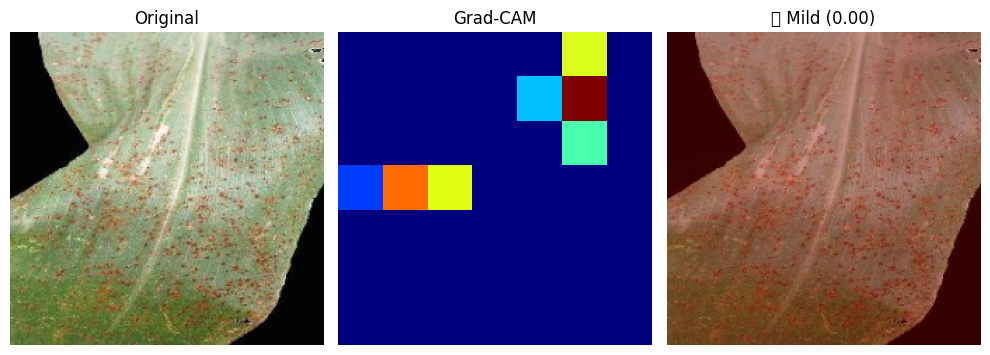


🟠 Moderate | Score=0.085 | C:\plant_village_split\test\Apple___Cedar_apple_rust\0321e067-d13b-47d0-b3a6-76ba6f357d02___FREC_C.Rust 3667.JPG


C:\Users\Admin\AppData\Local\Temp\ipykernel_18544\2675012859.py:95: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\Downloads\plant_disease_detection_project\dl_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


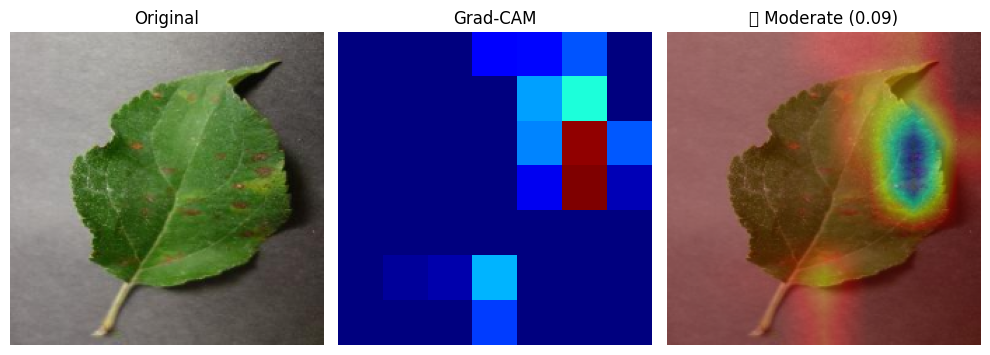


🔴 Severe | Score=0.260 | C:\plant_village_split\test\Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot\171b34fb-183f-4b57-be91-7e02fcebb7df___RS_GLSp 4326.JPG


C:\Users\Admin\AppData\Local\Temp\ipykernel_18544\2675012859.py:95: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\Downloads\plant_disease_detection_project\dl_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


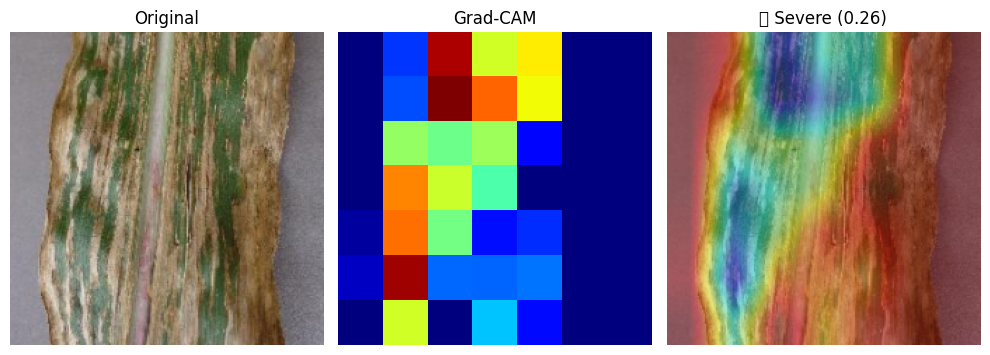

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from tensorflow.keras.preprocessing import image

# ---- Load trained model ----
model_path = r"C:\plant_village_model\effnet_cpu_best.keras"
model = tf.keras.models.load_model(model_path)
print("✅ Model loaded successfully.")

# ---- Grad-CAM heatmap function ----
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        pred_output = predictions[:, pred_index]
    grads = tape.gradient(pred_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)
    if isinstance(heatmap, tf.Tensor):
        heatmap = heatmap.numpy()
    return heatmap

# ---- Compute severity for an image ----
def get_severity_score(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)
    last_conv_layer_name = [layer.name for layer in model.layers if 'conv' in layer.name][-1]
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    return np.mean(heatmap), heatmap, img

# ---- Load test images ----
test_dir = r"C:\plant_village_split\test"
image_paths = []
for cls in os.listdir(test_dir):
    class_dir = os.path.join(test_dir, cls)
    if os.path.isdir(class_dir):
        for f in os.listdir(class_dir)[:2]:  # take a couple from each class
            image_paths.append(os.path.join(class_dir, f))

# ---- Compute severity for several images ----
scores = []
for path in image_paths[:15]:  # check first 15 images
    try:
        score, _, _ = get_severity_score(path)
        scores.append((path, score))
    except Exception as e:
        print(" Skipped:", path, "-", e)

# ---- Sort by severity score ----
scores.sort(key=lambda x: x[1])
mild_img = scores[0]
moderate_img = scores[len(scores)//2]
severe_img = scores[-1]

print("\n🟢 Mild:", mild_img)
print("🟠 Moderate:", moderate_img)
print("🔴 Severe:", severe_img)

# ---- Function to visualize ----
def show_gradcam(img_path, heatmap, severity_label):
    img_original = cv2.imread(img_path)
    img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
    img_original = cv2.resize(img_original, (224, 224))
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img_original, 0.6, heatmap_colored, 0.4, 0)

    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1)
    plt.imshow(img_original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(superimposed)
    plt.title(severity_label)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# ---- Display one Mild, one Moderate, one Severe ----
for (label, data) in zip(["🟢 Mild", "🟠 Moderate", "🔴 Severe"],
                         [mild_img, moderate_img, severe_img]):
    path, _ = data
    score, heatmap, _ = get_severity_score(path)
    print(f"\n{label} | Score={score:.3f} | {path}")
    show_gradcam(path, heatmap, f"{label} ({score:.2f})")


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, LearningRateScheduler
import os
import math

print("✅ TensorFlow running on:", "GPU" if tf.config.list_physical_devices('GPU') else "CPU")

# ====================================================
# Step 1 — Dataset Paths
# ====================================================
output_dir = r"C:\plant_village_split"
train_dir = os.path.join(output_dir, "train")
val_dir   = os.path.join(output_dir, "val")
test_dir  = os.path.join(output_dir, "test")

# ====================================================
# Step 2 — Data Generators
# ====================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 30  # a bit more

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input,
    rotation_range=35,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.25,
    shear_range=0.15,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False
)

# ====================================================
# Step 3 — Build & Compile Model
# ====================================================
base_model = EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze last 150 layers for deeper fine-tuning
for layer in base_model.layers[:-150]:
    layer.trainable = False
for layer in base_model.layers[-150:]:
    layer.trainable = True

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
output = layers.Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

# ====================================================
# Step 4 — Compile with label smoothing
# ====================================================
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

# ====================================================
# Step 5 — Learning rate schedule (cosine decay)
# ====================================================
def cosine_annealing(epoch, lr):
    initial_lr = 1e-4
    return initial_lr * 0.5 * (1 + math.cos(math.pi * epoch / EPOCHS))

lr_scheduler = LearningRateScheduler(cosine_annealing)

# ====================================================
# Step 6 — Callbacks
# ====================================================
checkpoint_path = r"C:\plant_village_model\effnet_cpu_best_v2.keras"
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_accuracy', save_best_only=True),
    lr_scheduler
]

# ====================================================
# Step 7 — Train
# ====================================================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ====================================================
# Step 8 — Evaluate on Test Data
# ====================================================
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n🚀 Final Test Accuracy: {test_acc * 100:.2f}%")


✅ TensorFlow running on: CPU
Found 12732 images belonging to 19 classes.
Found 1591 images belonging to 19 classes.
Found 1592 images belonging to 19 classes.
Epoch 1/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 1696s 2s/step - accuracy: 0.6599 - loss: 1.5989 - val_accuracy: 0.9302 - val_loss: 0.9057 - learning_rate: 1.0000e-04
Epoch 2/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 1075s 1s/step - accuracy: 0.8767 - loss: 1.0360 - val_accuracy: 0.9679 - val_loss: 0.8195 - learning_rate: 9.9726e-05
Epoch 3/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 999s 1s/step - accuracy: 0.9143 - loss: 0.9313 - val_accuracy: 0.9635 - val_loss: 0.7972 - learning_rate: 9.8907e-05
Epoch 4/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 986s 1s/step - accuracy: 0.9325 - loss: 0.8738 - val_accuracy: 0.9811 - val_loss: 0.7374 - learning_rate: 9.7553e-05
Epoch 5/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 1048s 1s/step - accuracy: 0.9471 - loss: 0.8315 - val_accuracy: 0.9793 - val_loss: 0.7346 - learning_rate: 9.5677e-05
Epoch 6/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 1042s 1s/step

In [8]:
from tensorflow.keras.models import load_model
model = load_model(r"C:\plant_village_model\effnet_cpu_best_v2.keras")
print("✅ Loaded best model successfully!")



✅ Loaded best model successfully!


In [5]:
import os, time
model_path = r"C:\plant_village_model\effnet_final.keras"
print("Model path exists:", os.path.exists(model_path))
print("Last modified:", time.ctime(os.path.getmtime(model_path)))


Model path exists: True
Last modified: Thu Nov  6 10:25:52 2025


In [7]:
import os, time, pprint

model_dir = r"C:\plant_village_model"
files = [os.path.join(model_dir,f) for f in os.listdir(model_dir) if f.endswith(".keras")]
files_info = [(f, time.ctime(os.path.getmtime(f))) for f in files]
files_info.sort(key=lambda x: x[1], reverse=True)  # newest first

print("Found .keras files (newest first):")
pprint.pprint(files_info, width=200)
# If nothing appears, you'll see an empty list -> model not saved


Found .keras files (newest first):
[('C:\\plant_village_model\\effnet_cpu_best_v2.keras', 'Wed Nov  5 21:41:44 2025'),
 ('C:\\plant_village_model\\best_model.keras', 'Thu Oct 30 19:48:47 2025'),
 ('C:\\plant_village_model\\effnet_final.keras', 'Thu Nov  6 10:25:52 2025'),
 ('C:\\plant_village_model\\effnet_final_99.keras', 'Thu Nov  6 10:21:20 2025'),
 ('C:\\plant_village_model\\effnet_cpu_best.keras', 'Sun Nov  2 20:13:19 2025')]


In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# --- Paths ---
model_path = r"C:\plant_village_model\effnet_cpu_best_v2.keras"   
test_dir = r"C:\plant_village_split\test"                         

# --- Load model ---
model = tf.keras.models.load_model(model_path)
print("Model loaded successfully from:", model_path)

# --- Prepare test data generator ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# --- Evaluate model on test set ---
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n🚀 Final Test Accuracy: {test_acc * 100:.2f}%")


Model loaded successfully from: C:\plant_village_model\effnet_cpu_best_v2.keras
Found 1592 images belonging to 19 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 75s 672ms/step - accuracy: 0.9893 - loss: 0.6321

🚀 Final Test Accuracy: 98.93%


100/100 ━━━━━━━━━━━━━━━━━━━━ 88s 838ms/step


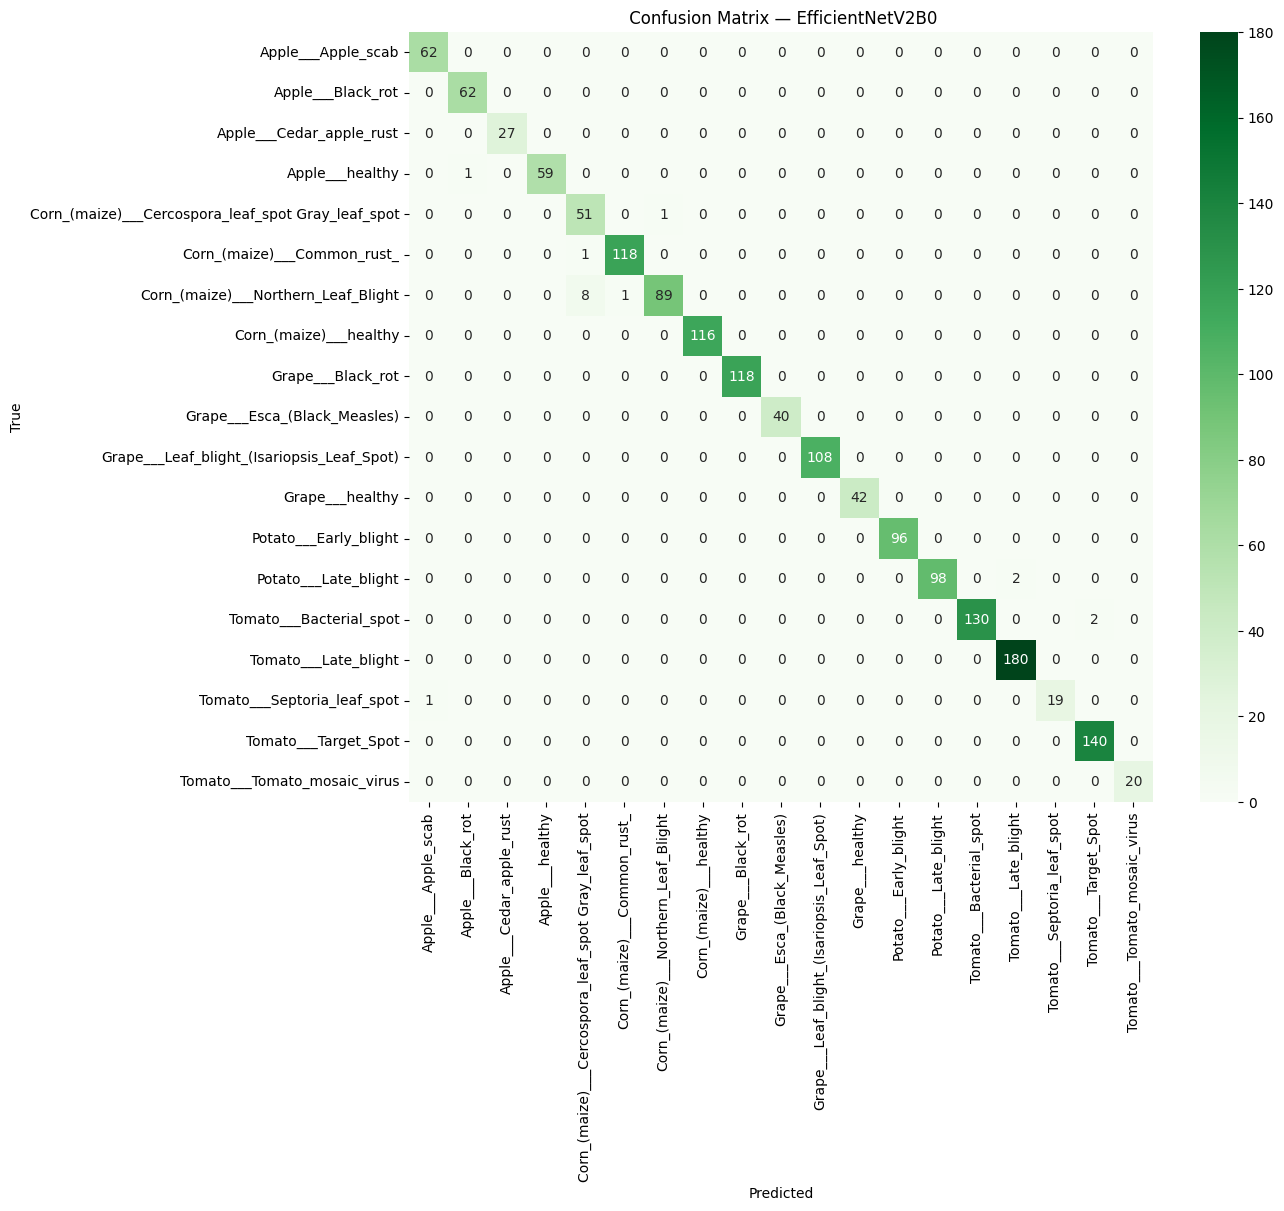


Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      1.00      0.99        62
                                 Apple___Black_rot       0.98      1.00      0.99        62
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        27
                                   Apple___healthy       1.00      0.98      0.99        60
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.85      0.98      0.91        52
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       119
               Corn_(maize)___Northern_Leaf_Blight       0.99      0.91      0.95        98
                            Corn_(maize)___healthy       1.00      1.00      1.00       116
                                 Grape___Black_rot       1.00      1.00      1.00       118
                      Grape___Esca_(Black_Measles)    

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# --- Predictions ---
preds = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title(" Confusion Matrix — EfficientNetV2B0")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# --- Classification Report ---
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


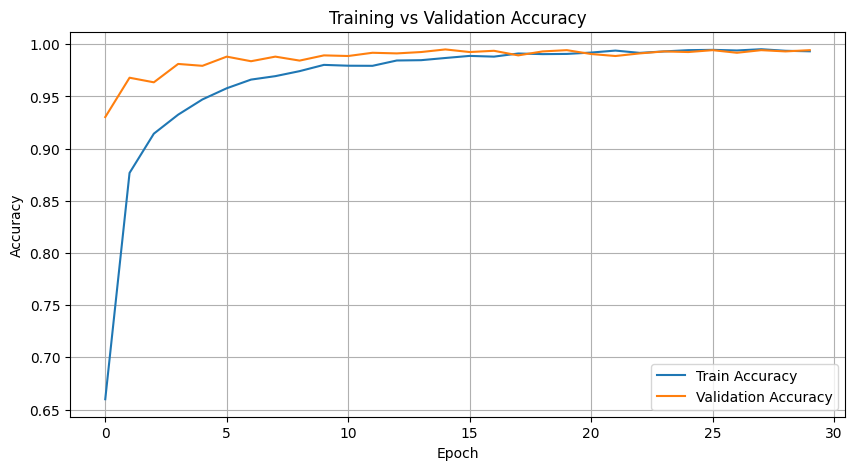

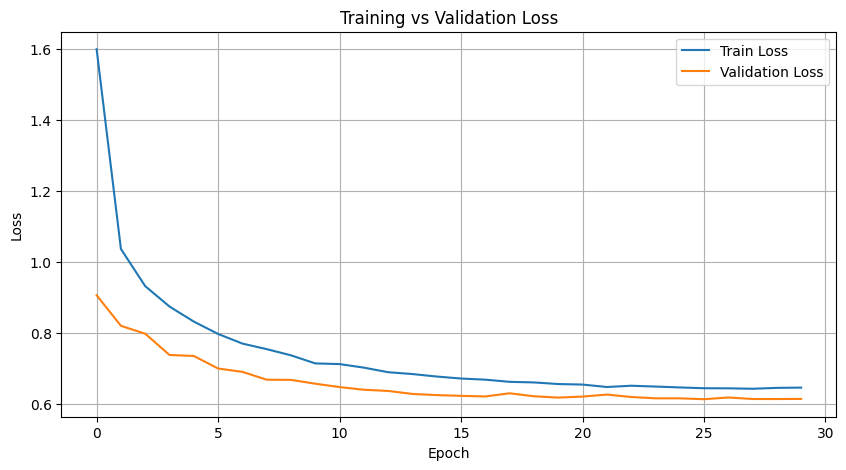

In [10]:
import matplotlib.pyplot as plt

acc = [0.6599, 0.8767, 0.9143, 0.9325, 0.9471, 0.9578, 0.9661, 0.9694, 0.9742, 0.9802, 
       0.9794, 0.9793, 0.9844, 0.9847, 0.9868, 0.9888, 0.9881, 0.9911, 0.9905, 0.9907,
       0.9920, 0.9939, 0.9917, 0.9931, 0.9943, 0.9946, 0.9940, 0.9952, 0.9937, 0.9932]

val_acc = [0.9302, 0.9679, 0.9635, 0.9811, 0.9793, 0.9881, 0.9837, 0.9881, 0.9843, 0.9893,
            0.9887, 0.9918, 0.9912, 0.9925, 0.9950, 0.9925, 0.9937, 0.9893, 0.9931, 0.9943,
            0.9906, 0.9887, 0.9912, 0.9931, 0.9925, 0.9943, 0.9918, 0.9943, 0.9931, 0.9943]

loss = [1.5989, 1.0360, 0.9313, 0.8738, 0.8315, 0.7966, 0.7695, 0.7538, 0.7364, 0.7136,
        0.7117, 0.7017, 0.6888, 0.6836, 0.6766, 0.6710, 0.6678, 0.6617, 0.6600, 0.6555,
        0.6540, 0.6471, 0.6507, 0.6484, 0.6459, 0.6437, 0.6434, 0.6422, 0.6447, 0.6454]

val_loss = [0.9057, 0.8195, 0.7972, 0.7374, 0.7346, 0.6992, 0.6898, 0.6677, 0.6672, 0.6564,
             0.6469, 0.6394, 0.6360, 0.6276, 0.6243, 0.6222, 0.6205, 0.6294, 0.6210, 0.6173,
             0.6201, 0.6258, 0.6190, 0.6152, 0.6152, 0.6127, 0.6176, 0.6133, 0.6132, 0.6136]

# Plot Accuracy
plt.figure(figsize=(10,5))
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


 Model loaded successfully.

 Mild: ('C:\\plant_village_split\\test\\Corn_(maize)___Common_rust_\\RS_Rust 1583.JPG', 0.003585929)
 Moderate: ('C:\\plant_village_split\\test\\Apple___Cedar_apple_rust\\0321e067-d13b-47d0-b3a6-76ba6f357d02___FREC_C.Rust 3667.JPG', 0.08503819)
 Severe: ('C:\\plant_village_split\\test\\Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot\\171b34fb-183f-4b57-be91-7e02fcebb7df___RS_GLSp 4326.JPG', 0.2600393)

 Mild | Severity Score = 0.004 | Image = RS_Rust 1583.JPG


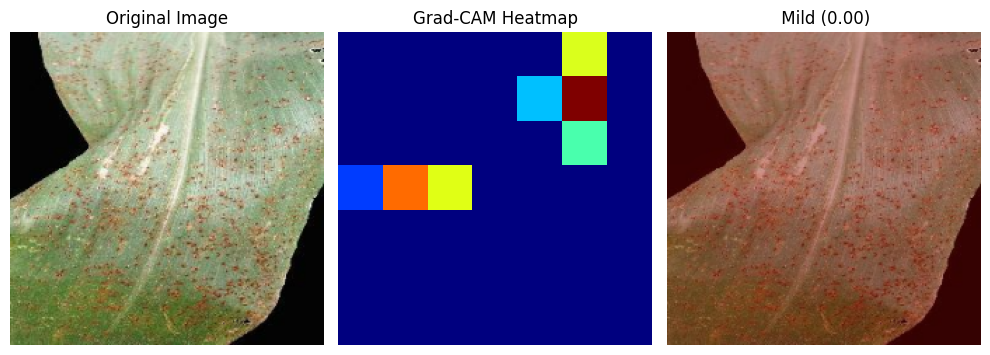


 Moderate | Severity Score = 0.085 | Image = 0321e067-d13b-47d0-b3a6-76ba6f357d02___FREC_C.Rust 3667.JPG


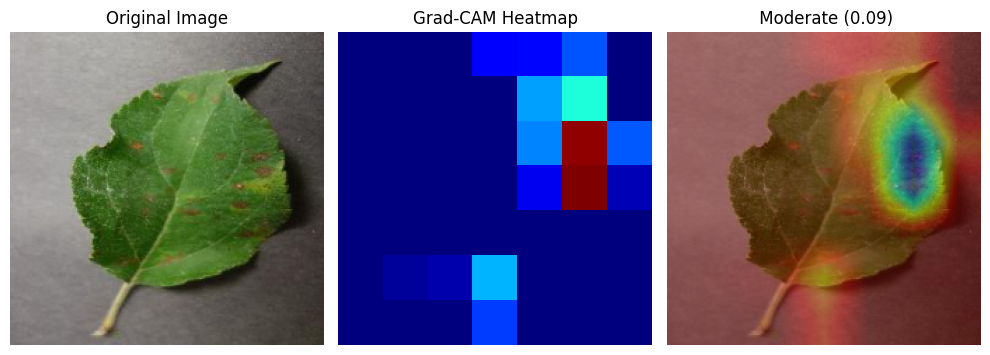


 Severe | Severity Score = 0.260 | Image = 171b34fb-183f-4b57-be91-7e02fcebb7df___RS_GLSp 4326.JPG


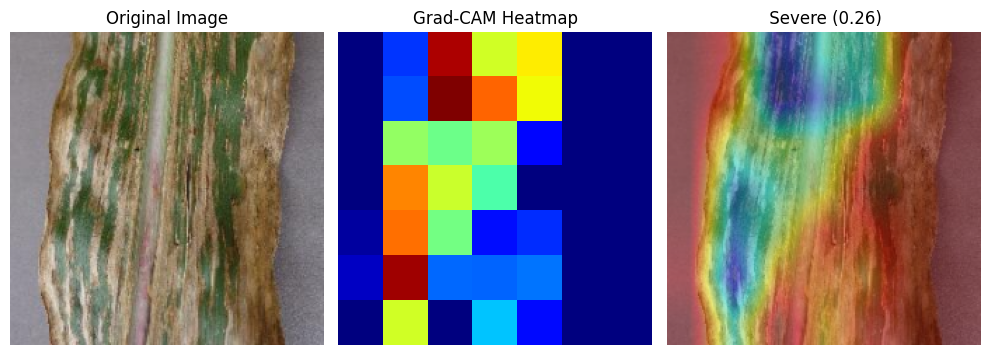

In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from tensorflow.keras.preprocessing import image

# =====================================================
# Step 1 — Load the trained model
# =====================================================
model_path = r"C:\plant_village_model\effnet_cpu_best.keras"  # adjust if different
model = tf.keras.models.load_model(model_path)
print(" Model loaded successfully.")

# =====================================================
# Step 2 — Grad-CAM Heatmap Function
# =====================================================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        pred_output = predictions[:, pred_index]

    grads = tape.gradient(pred_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)

    if isinstance(heatmap, tf.Tensor):
        heatmap = heatmap.numpy()

    return heatmap

# =====================================================
# Step 3 — Compute Severity for an Image
# =====================================================
def get_severity_score(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)

    last_conv_layer_name = [layer.name for layer in model.layers if 'conv' in layer.name][-1]
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    severity_score = np.mean(heatmap)
    return severity_score, heatmap, img

# =====================================================
# Step 4 — Load Test Images
# =====================================================
test_dir = r"C:\plant_village_split\test"
image_paths = []
for cls in os.listdir(test_dir):
    class_dir = os.path.join(test_dir, cls)
    if os.path.isdir(class_dir):
        for f in os.listdir(class_dir)[:2]:
            image_paths.append(os.path.join(class_dir, f))

# =====================================================
# Step 5 — Calculate Severity Scores
# =====================================================
scores = []
for path in image_paths[:15]:
    try:
        score, _, _ = get_severity_score(path)
        scores.append((path, score))
    except Exception as e:
        print(" Skipped:", path, "-", e)

scores.sort(key=lambda x: x[1])
mild_img = scores[0]
moderate_img = scores[len(scores)//2]
severe_img = scores[-1]

print("\n Mild:", mild_img)
print(" Moderate:", moderate_img)
print(" Severe:", severe_img)

# =====================================================
# Step 6 — Visualization Function
# =====================================================
def show_gradcam(img_path, heatmap, severity_label):
    img_original = cv2.imread(img_path)
    img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
    img_original = cv2.resize(img_original, (224, 224))

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img_original, 0.6, heatmap_colored, 0.4, 0)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img_original)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(superimposed)
    plt.title(severity_label)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# =====================================================
# Step 7 — Show Mild, Moderate, Severe Examples
# =====================================================
for (label, data) in zip([" Mild", " Moderate", " Severe"],
                         [mild_img, moderate_img, severe_img]):
    path, _ = data
    score, heatmap, _ = get_severity_score(path)
    print(f"\n{label} | Severity Score = {score:.3f} | Image = {os.path.basename(path)}")
    show_gradcam(path, heatmap, f"{label} ({score:.2f})")


In [1]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# ====================================================
# ---- Paths ----
# ====================================================
model_path = r"C:\plant_village_model\effnet_cpu_best_v2.keras"
image_path = r"C:\Users\Admin\Downloads\IMG-common-rust.jpg"   # change this to your own image
test_dir = r"C:\plant_village_split\test"

# ====================================================
# ---- Load model ----
# ====================================================
model = tf.keras.models.load_model(model_path)
print(" Model loaded successfully!")

# ====================================================
# ---- Load & preprocess image ----
# ====================================================
IMG_SIZE = (224, 224)
img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

# ====================================================
# ---- Predict class ----
# ====================================================
pred = model.predict(img_array)
class_idx = np.argmax(pred)
confidence = np.max(pred) * 100

# ---- Get class labels ----
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE, batch_size=16, class_mode="categorical")
class_labels = list(test_generator.class_indices.keys())
predicted_class = class_labels[class_idx]

print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

# ====================================================
# ---- Grad-CAM Heatmap ----
# ====================================================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        pred_output = predictions[:, pred_index]

    grads = tape.gradient(pred_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)

    return heatmap.numpy()

# ---- Get last convolution layer automatically ----
last_conv_layer_name = [layer.name for layer in model.layers if 'conv' in layer.name][-1]
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# ====================================================
# ---- Severity Estimation ----
# ====================================================
severity_score = np.mean(heatmap) * 100
if severity_score < 25:
    severity_label = "Mild"
elif severity_score < 50:
    severity_label = " Moderate"
else:
    severity_label = " Severe"

print(f" Severity Score: {severity_score:.2f}% ({severity_label})")

# ====================================================
# ---- Visualization ----
# ====================================================
img_original = cv2.imread(image_path)
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
img_original = cv2.resize(img_original, (224, 224))

heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
superimposed = cv2.addWeighted(img_original, 0.6, heatmap_colored, 0.4, 0)

plt.figure(figsize=(14,5))
plt.subplot(1,3,1)
plt.imshow(img_original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(superimposed)
plt.title(f"{severity_label} ({severity_score:.1f}%)")
plt.axis("off")
plt.tight_layout()
plt.show()


 Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Found 1592 images belonging to 19 classes.
Predicted Class: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Confidence: 63.99%


AttributeError: 'numpy.ndarray' object has no attribute 'numpy'